---
# **SEMTM0016 Coursework - Artificial Intelligence in Robotics Report**
---

## **Introduction**

This report presents a comprehensive understanding of Machine Learning (ML) models, specifically focusing on the implementation, optimization.It also critical evaluate of different algorithms such as **Supervised (SL)**, **Unsupervised (USL)**, and **Reinforcement Learning (RL)**. 

The objective is to demonstrate technical proficiency in **Algorithm Selection**, where specific algorithms are justified through data analysis and the underlying project requirements, and **Integrated Evaluation** where different ML models are assessed not as isolated components but as interconnected stages within a unified data pipeline that collectively determine system performance.

To demonstrate these competencies in a realistic context, this project adopts a **narrative-driven approach** to machine learning, where a gamified ***Hero Bot and the MazeDungeon*** is mapped to a imaginary ***Industrial Operational Technology (OT) framework***.

### **Narrative -** Smart Factory Integration

**Problem Statement**

In an automated industrial facility, continuous monitoring of different types of robotic assets is important and yet challenging. The core problem addressed in this pipeline is the development of an autonomous inspection system capable of physical navigation and multi-modal data validation.

The checking agent will autonomously navigate the complex, *maze-like layout of the factory floor* to locate different robots dynamically spawned at various locations. Once an asset location is reached, the system must validate robot telemetry and classify visual images against baseline standards. This ensures that every robot on the floor is operating safely and accurately, bridging the gap between physical navigation and data-driven oversight.

To solve this inspection challenge, the project integrates three distinct machine learning algorithm instead operating in isolation. These models will converge whenever the checking agent encounters a spawned robot on the factory floor:
1. **The Navigator (Reinforcement Learning) -** The physical layout of the facility is modeled as a complex maze. The RL agent's primary objective is to autonomously traverse generated grid to locate various target locations where different robots (asset) have been spawned. Rather than pursuing a single optimal route, the system compares different control strategies that balance aggressive, reward-driven path against conservative and step-optimized navigation to reliably reach inspection sites.
2. **Telemetry Validation (Supervised Learning) -** Upon successfully navigating to a spawned robot, the first phase of the inspection check begins. This module analyzes the robot's telemetry data . It classifies the asset type, verifying that the live telemetry perfectly matches the verified and true state of the machine.
3. **Visual Classification (Unsupervised Learning) -** Simultaneously, the inspection utilizes visual sensor data. The Visual Classification module extracts features from the images of the asset present there and groups them into clusters. This allows the system to evaluate whether the visual profile of the spawned asset aligns correctly with the expected cluster patterns, ensuring visual integrity without using hard-coded labels.

The entire pipeline is evaluated through three levels of specialized checks at the specific locations of the spawned robots. By combining the RL agent's navigation success with the Supervised Learning's telemetry accuracy and the Unsupervised Learning's visual clustering alignment, the system computes a comprehensive operational health score for each asset encountered.

---

### <a id="map"></a> **Mapping and Setting up the Narrative Architecture**

To bridge the gap between the provided gamified names and the industrial use case, the original elements have been systematically renamed and mapped to an Industrial Operational framework.

**Note - No attempt was made to change or alter the data, the data is only renamed to fit the narrative**

1. *dungeon images colour80* -> *DATASET*
    * human     -> robotic_arm - Due to the fact, both share structural similarity of human arm
    * orc       -> cnc_machines - Due to the fact, both are heavy, robust entities 
    * hafling   -> plc_controller - Due to the fact, both are small but highly capable
    * wingedrat -> drone - Due to the fact, both can fly
    * lizard    -> agv_unit - Due to the fact, both can fly and navigate on ground 
2. *dungeon sensorstats.csv* -> *SENSOR_STATS.csv*
    * species       -> asset_class - Both fundamental categorical type
    * stench        -> voc_emissions - Due to Olfactory output
    * sound         -> acoustic_vibration - Due to Auditory output
    * intelligence  -> cpu_utilization - Due to Mental capacity
    * weight        -> mechanical_load - Due to Physical mass
    * height        -> elevation_altitude - Due to Vertical stature
    * strength      -> actuator_torque - Due to Physical power
    * heat          -> thermal_load - Due to Temperature output
    * magic         -> remote_override_flag - Due to manual, out-of-band administrative overrides.
    * flight        -> airborne_status - Due to Ablity to fly
    * bribe         -> compromise_risk_index - Due Susceptibility to influence by threats

In [4]:
# FOR MAPPING
from pathlib import Path
from Env.mapping import map_csv, map_imgs

IMG_PATH = "DATA/DATASET"
CSV_PATH = "DATA/SENSOR_STATS.csv"
PLOT_PATH = "PLOTS/"
MODEL_PATH = "MODELS/"
SEED = 47 # Fixing Seed for Reproducablity
if not Path(CSV_PATH).exists(): map_csv()
if not Path(IMG_PATH).exists(): map_imgs()
Path(PLOT_PATH).mkdir(parents=True, exist_ok=True) # For All Plots
Path(MODEL_PATH).mkdir(parents=True, exist_ok=True) # For All Models

Note - ***mapping.py*** in "Env" Folder

---

## <a id="flow"></a> Flow of Report
1. Introduction
2. [Mapping and Setting up the Narrative Architecture](#map)
3. [Flow of Report](#flow)
4. Algorithm Training
    1. [Reinforcement Learning](#rl_t)
        1. [Introduction to Problem](#rl_t_intro)
        2. [Justification for Algorithm Choice](#rl_t_why)
        3. [Implementation and Data Flow of Both Method](#rl_t_m)
        4. [Comparative Training Analysis](#rl_t_eval)
    2. [Supervised Learning](#sl_t)
        1. [Introduction to Problem](#sl_t_intro)
        2. [Justification for Algorithm Choice](#sl_t_why)
        3. [Implementation and Data Flow of Both Method](#sl_t_m)
        4. [Comparative Training Analysis](#sl_t_eval)
    3. [UnSupervised Learning](#usl_t)
        1. [Introduction to Problem](#usl_t_intro)
        2. [Justification for Algorithm Choice](#usl_t_why)
            1. [Implementation and Data Flow of Method 1](#usl_t_m1)
            2. [Implementation and Data Flow of Method 2](#usl_t_m2)
        3. [Comparative Training Analysis](#usl_t_eval)
5. Integrated Inference
    1. [Data Flow and Implementation](#infer)
    2. [Comparison Supervised Learning Inference](#sl_i)
    3. [Comparison UnSupervised Learning Inference](#usl_i)
    4. [Comparison Reinforcement Learning Inference](#rl_i)
    5. [Comparison different Combination of Models](#all_i)
6. [Conclusion](#con)

[Back to Mapping](#map)

---

## **4. Training Algorithm**

### <a id="rl_t"></a> 4.1 Reinforcement Learning

[Back to Flow](#flow)

#### <a id="rl_t_intro"></a> 4.1.1 Introduction to Problem

In Industrial environments, inspection operates under conflicting constraints. The Navigator module addresses two primary objectives: Safety Assurance versus Time Efficiency.

The Inspection Agent navigates the facility floor matrix to locate spawned robotic assets under two distinct security protocols:
* **Quick Scan (Routine Sweep)** — During standard operations, the agent reaches target nodes as rapidly as possible to minimize inspection downtime. Priority is raw efficiency, finding the shortest path while assuming that comprehensive coverage of critical nodes implies facility-wide security.
* **Deep Scan (High-Security Sweep)** — During elevated threat levels or maintenance windows, priority shifts entirely to safety. The agent navigates the entire environment with security checks at every location, accepting detours and longer routes to guarantee inspection unit security.

A simple 10x10 grid map is generated with 40 walkable grid (rest are blocked) and out of that 10 position are selected where robot will be spawned.

1. **env_gen.py** -> For generating map (maze)
    1. INITIALIZATION (Input: seed)
        * DATA FLOW: seed -> random/numpy generators -> grid object
        * Initialize a 10x10 zeroed NumPy array (the "Grid")
        * Define static coordinates for Entry(0,1), Exit(8,9), and Inner boundaries
    2. GENERATE PATH SPINE (The "Main Road")
        * DATA FLOW: (1,1) -> path_cells set (tracks unique coordinates)
        * Starting at (1,1), randomly move Right or Down until reaching (8,8)
        * Add every step's coordinate to the 'path_cells' collection
    3. PROCEDURAL GROWTH (Expanding the Path)
        * DATA FLOW: path_cells -> neighbor check -> path_cells (grows to size 38)
        * While total unique path cells < 38:
            - Pick a random existing path cell
            - Look at its 4 adjacent neighbors (North, South, East, West)
            - IF neighbor is within (1-8) bounds AND not already in path:
        * Add it to 'path_cells'
    4. MAP ASSEMBLY & SPAWNERS
        * DATA FLOW: path_cells -> grid array (1s) -> spawners list (10 random samples)
        * Update the NumPy grid: Set all 'path_cells' coordinates to 1
        * Force Entry/Exit cells to 1
        * Randomly pick 10 coordinates from 'path_cells' to be 'spawners' (loaction where agent perform checks)
        * Return the final Grid (array) and Spawner list
    5. VISUALIZATION
        * DATA FLOW: grid + spawners + constants -> Matplotlib colormap -> PNG file
        * Create a copy of the grid for rendering
        * Assign unique integers (2, 3, 4) to Spawners, Entry, and Exit for color mapping
        * Plot using pcolor with a custom 5-color palette
        * Save result

2. **env_scoring.py** -> For Environment Logic & Rewards
    1. INITIALIZATION (The Environment State)
        * DATA FLOW: Map data (grid, spawners, entry, exit) -> EnvMap Object
        * Stores the map layout and defines the Action Space (0: Up, 1: Down, 2: Left, 3: Right).
        * Maps integer actions to coordinate changes (e.g., 0 becomes (-1, 0)).
    2. RESET (Starting a New Round)
        * DATA FLOW: Entry coordinates -> Agent Position; Reset bitmask to 0
        * Places the agent back at the start (0, 1).
        * Bitmask Logic: Sets self.visited to 0. This is an integer used as a "checklist" to track which of the 10 spawners have been visited using binary bits.
    3. STEP & MOVEMENT (The Physics)
        * DATA FLOW: Action (Int) -> New Coordinates -> Boundary/Wall Check
        * Calculates the target cell.
        * Collision Detection: If the new cell is outside the 10x10 grid or is a Wall (0), the move is canceled, and the agent receives a -5 penalty.
    4. SCORING & BITMASKING (The Goal)
        * DATA FLOW: Agent Position -> Spawner List -> visited Bitmask -> Reward
        * Step Penalty: Every move costs -1 to encourage the agent to be fast.
        * Spawner Reward: If the agent hits a spawner it hasn't seen before:
            - The corresponding bit in the bitmask is flipped to 1.
            - Agent receives a +50 bonus.
        * Exit Logic: If the agent reaches the Exit:
            - Perfect Run: If bitmask is 1023 (all 10 spawners visited), +500 bonus.
            - Partial Run: Receives a smaller reward based on how many spawners were missed. *<reward += max(0,100 - (missed * 10))>*
    5. TERMINATION (End of Episode)
        * DATA FLOW: complete boolean -> Agent
        * The episode ends if:
            - The agent reaches the Exit.
            - The agent exceeds 250 steps (prevents infinite loops).

3. **spanwer.py** -> For Data Payload Retrieval
    1. INITIALIZATION (Loading the Database)
        * DATA FLOW: csv_path + image_dir -> DataSpawner Object.
        * Loads a CSV file containing tabular technical data into a Pandas DataFrame.
        * Defines the 5 asset categories (Robotic Arm, PLC, AGV, Drone, CNC).
    2. ASSET ASSIGNMENT (Mapping Nodes to Equipment)
        * DATA FLOW: Asset Classes -> generate_node() -> self.node (List of 10).
        * Logic: It ensures variety by picking one of each of the 5 classes, then adds 5 more at random.
        * Result: Each of your 10 spawner nodes on the map is now assigned a specific type of industrial equipment to "inspect."
    3. PAYLOAD GENERATION (Sampling the Inspection Data)
        * DATA FLOW: node_idx -> Target Class -> Filtered Data -> Final Payload.
        * Filtering: It looks at the CSV and finds rows matching the node's asset type.
        * Condition Check: It groups data by airborne_status and remote_override_flag to find a "stable" group of at least 100 records.
        * Image Retrieval: It navigates the OS folder structure (image_dir/asset_class) to find 100 corresponding .png images.
    4. DATA DELIVERY (The "Inspection Report")
        * DATA FLOW: Returns a Tuple: (class, tabular_rows, image_paths, air_status, override_status).
        * This represents the "packet" of data the agent successfully collects when it reaches a spawner node.

**In short: These builds the map, defines the navigation logic, and populates the world with data for an agent to check.**

Inference receives a packets of list containing: target_class, sampled_rows, image_paths, current_air, and current_override. 

The image_paths has 100 image path of the target_class, while sampled_rows contain 100 corresponding data entries from CSV where current_air and current_override remain constant across all target_class instances. - Reason Explained later in report.

Visual map saved


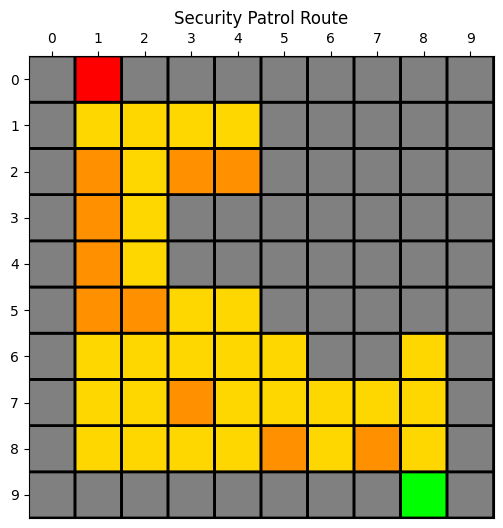

In [6]:
from Env.env_gen import MapGenerator

map = MapGenerator(seed=SEED)
map.generate_map()
map.visualize()

---

#### <a id="rl_t_why"></a> **4.1.2 Justification for Algorithm Choice** (Q Learning vs SARSA)

So, to fulfill the requirements of the "Quick Scan" and "Deep Scan" protocols, the algorithms must optimize different success criteria within the industrial environment. The reward structure penalizes collisions (−5) and rewards massively(+500) for a Perfect run (visiting all 10 nodes). Based on Temporal Difference learning theory, we hypothesize that Q-Learning (off-policy) and SARSA (on-policy) naturally map to our two protocols.

1. Q-Learning (Off-Policy)
    * Mechanism: Q-Learning updates its value estimates based on the maximum possible future reward, acting entirely independent of the agent's current exploratory actions.
    * Advantage: This assumes perfect future execution, so, it is mathematically unbothered by the risk of random collisions. It will greedily pursue the massive (+500) bonus, choosing an exhaustive, complex route to hit every single inspection node.
    * Disadvantage: It is aggressively optimistic. By ignoring the inherent risks of a tight, hazardous layout, it may plot routes with zero safety margins.
2. SARSA (On-Policy)**
    * Mechanism: SARSA incorporates the agent's actual next action—including its own random exploration rate (epsilon -greedy)—into its value updates.
    * Advantage: It is inherently risk-averse. Because SARSA "knows" its own randomness might cause it to crash into a wall and suffer a (-5) penalty It should naturally learn a safer and more direct route to the exit, inspite of securing a partial reward without taking damage.
    * Disadvantage: It will likely result in sub-optimal data collection, sacrificing the validation of several peripheral nodes to ensure a safe, rapid extraction.

**Hypothesis**

According to our hypothesis, Q-Learning is ideal for the Deep Scan, where scans all possibl locations and do validation checks (hitting all nodes), prioritizing rewards over route simplicity. And SARSA perfectly models the Quick Scan, prioritizing a fast, physically secure exit over exhaustive checks.

**Hyperparameter Optimization and Selection**
Identical hyperparameters were explicitly chosen for both Q-Learning and SARSA to ensure that any difference in their behavior during inference comes from how the algorithms work mathematically, not from different settings.
1. Learning Rate (alpha = 0.1) - It determines to which extend the newly acquired information overrides existing Q-table values.
    * Justification - To ensure stable convergence. In Q Learning, this allows slow construction of routes. For SARSA, this prevents from breaking an established safe route and smoothly integrated into the policy.
2. Discount Factor (gamma = 0.95) - It dictates the weight of future rewards versus immediate rewards.
    * Justification: High gamma is absolute nessacity for our hypothesis. Without this, Q learning would never be able to see the massive rewards of +500 at end and would not do the deep scan. While for SARSA, this ensures the agent evaluates long-term cumulative risk across the long journey, it opts for a shorter, safer route for "Quick Scan.
3. Initial Exploration Rate (epsilon = 1.0) - Its the probability of taking a random action.
    * Justification: Starting 100% randomn is mandatory. As the agent spawns with a completely empty Q-table ([0.0, 0.0, 0.0, 0.0]). To discover the 10 randomized Inspection Nodes scattered across the facility matrix, it must begin with pure, unguided exploration.
4. Epsilon Decay Rate (ep_decay = 0.999) - It's speed from random exploration to strict policy exploitation.
    * Justification: It is choosen to be slow because, Q-Learning requires more time to accidentally stumble upon all 10 nodes to do the Deep Scan, while SARSA needs this to experience enough wall collisions to learn its low risk route for quick scan.
5.  Minimum Epsilon (min_ep = 0.01) - It determines ablity to explore.
    * Justification: It ensures the agents never completely stop exploring, preventing them from getting trapped in local optima.

#### <a id="#rl_t_m"></a> **4.1.3 Implementation and Data Flow of Both the models**

Q-Learning and SARSA share the same Temporal Difference architecture and only their update rules differ only mathematically in how they evaluate the next state. So both runs within a single unified class with a if condition based on name which update rule applies. This ensures our goal of getting training variations result solely from their on-policy and off-policy mechanics, not structural differences.

1. **rl_models.py** -> For Agent Learning & Memory
    1. INITIALIZATION (The Memory & Hyperparameters)
        * DATA FLOW: Hyperparameters (alpha, gamma, epsilon$) -> RLModels Base Class
        * The Q-Table: Initializes a blank dictionary (self.qtable) that defaults to [0.0, 0.0, 0.0, 0.0] for any new state it encounters. This maps a state to the expected value of taking each of the 4 actions (Up, Down, Left, Right).
    2. ACTION SELECTION (Exploration vs. Exploitation)
        * DATA FLOW: Current State -> Epsilon Check -> Chosen Action (Int: 0-3)
        * Logic (epsilon -greedy):
            - Generates a random number.
            - If the number is < epsilon: Pick a completely random action (Explore).
            - Otherwise: Look at the Q-table for the current state and pick the action with the highest score (Exploit).
        * Decay: The decay_ep() function slowly shrinks epsilon over time so the agent explores less and exploits more as it gets smarter.
    3. Q-LEARNING (The Optimist - Off-Policy)
        * DATA FLOW: (state, action, reward, next_state) -> Q-Learning Formula -> Updated Q-Table
        * Logic: Updates the value of the action just taken. 
        * It looks at the next_state and assumes it will take the absolute best action available there, regardless of whether it actually will (it ignores epsilon for the update). It is aggressive and seeks the most optimal path.
    4. SARSA (The Realist - On-Policy)
        * DATA FLOW: (state, action, reward, next_state, next_action) -> SARSA Formula -> Updated Q-Table
        * Logic: Updates the value of the action just taken.
        * Unlike Q-Learning, it looks at the actual next_action the agent has decided to take (which might be a random, sub-optimal exploratory move). This makes SARSA more cautious, penalizing paths that run too close to walls if exploration causes accidental bumps.
    5. MODEL SAVING (Memory Persistence)
        * DATA FLOW: Python Dictionary (qtable) -> JSON Formatting -> .json File on Disk
        * Converts the memory map into strings and saves it as either q_brain.json or sarsa_brain.json so you don't have to retrain the agent every time you run the project.

2. **train_rl_models.py** -> For Running the Training
    1. INITIALIZATION (The Setup)
        * DATA FLOW: Settings (Episodes, Seed, Paths) -> RLTraining Object
        * Stores the configuration for how long the training should run and where to save the outputs.
        * Maps strings ("q", "sarsa") to their respective mathematical classes.
    2. ENVIRONMENT CREATION (make_env)
        * DATA FLOW: Seed -> MapGenerator -> Grid/Spawners -> EnvMap
        * Generates the physical 10x10 map using your specific seed.
        * Wraps that map in the EnvMap class so it can enforce the rules, boundaries, and rewards.
    3. THE TRAINING LOOP (run_model)
        * DATA FLOW: State -> Action -> Env -> (Next State, Reward) -> Learning Formula
        * For every episode (e.g., 5000 times):
            - Reset the map. Get the starting_state.
            - Ask the model's brain to pick an action.
            - While the agent hasn't hit the exit or timed out:
                - Execute the action in the environment.
                - Receive the next_state, the reward, and whether the run is complete.
                - Ask the brain for the next_action.
                - Learn: Send all this data to the model's formula (passing next_action as well if it's SARSA).
                - Update the current state and action to the new ones.
        * At the end of the episode, shrink epsilon (decay_ep()) so the agent explores less and exploits more. Record the total reward.
    4. SAVING & VISUALIZATION (train_rl_models)
        * DATA FLOW: Reward History + Timers -> Matplotlib -> JPEG Files
        * Runs the entire simulation for Q-Learning. Saves the model and plots the learning curve.
        * Runs the entire simulation for SARSA. Saves the model and plots the learning curve.
        * Passes both histories into a final comparison utility to generate a side-by-side performance graph (rl_model_comparison.jpeg).

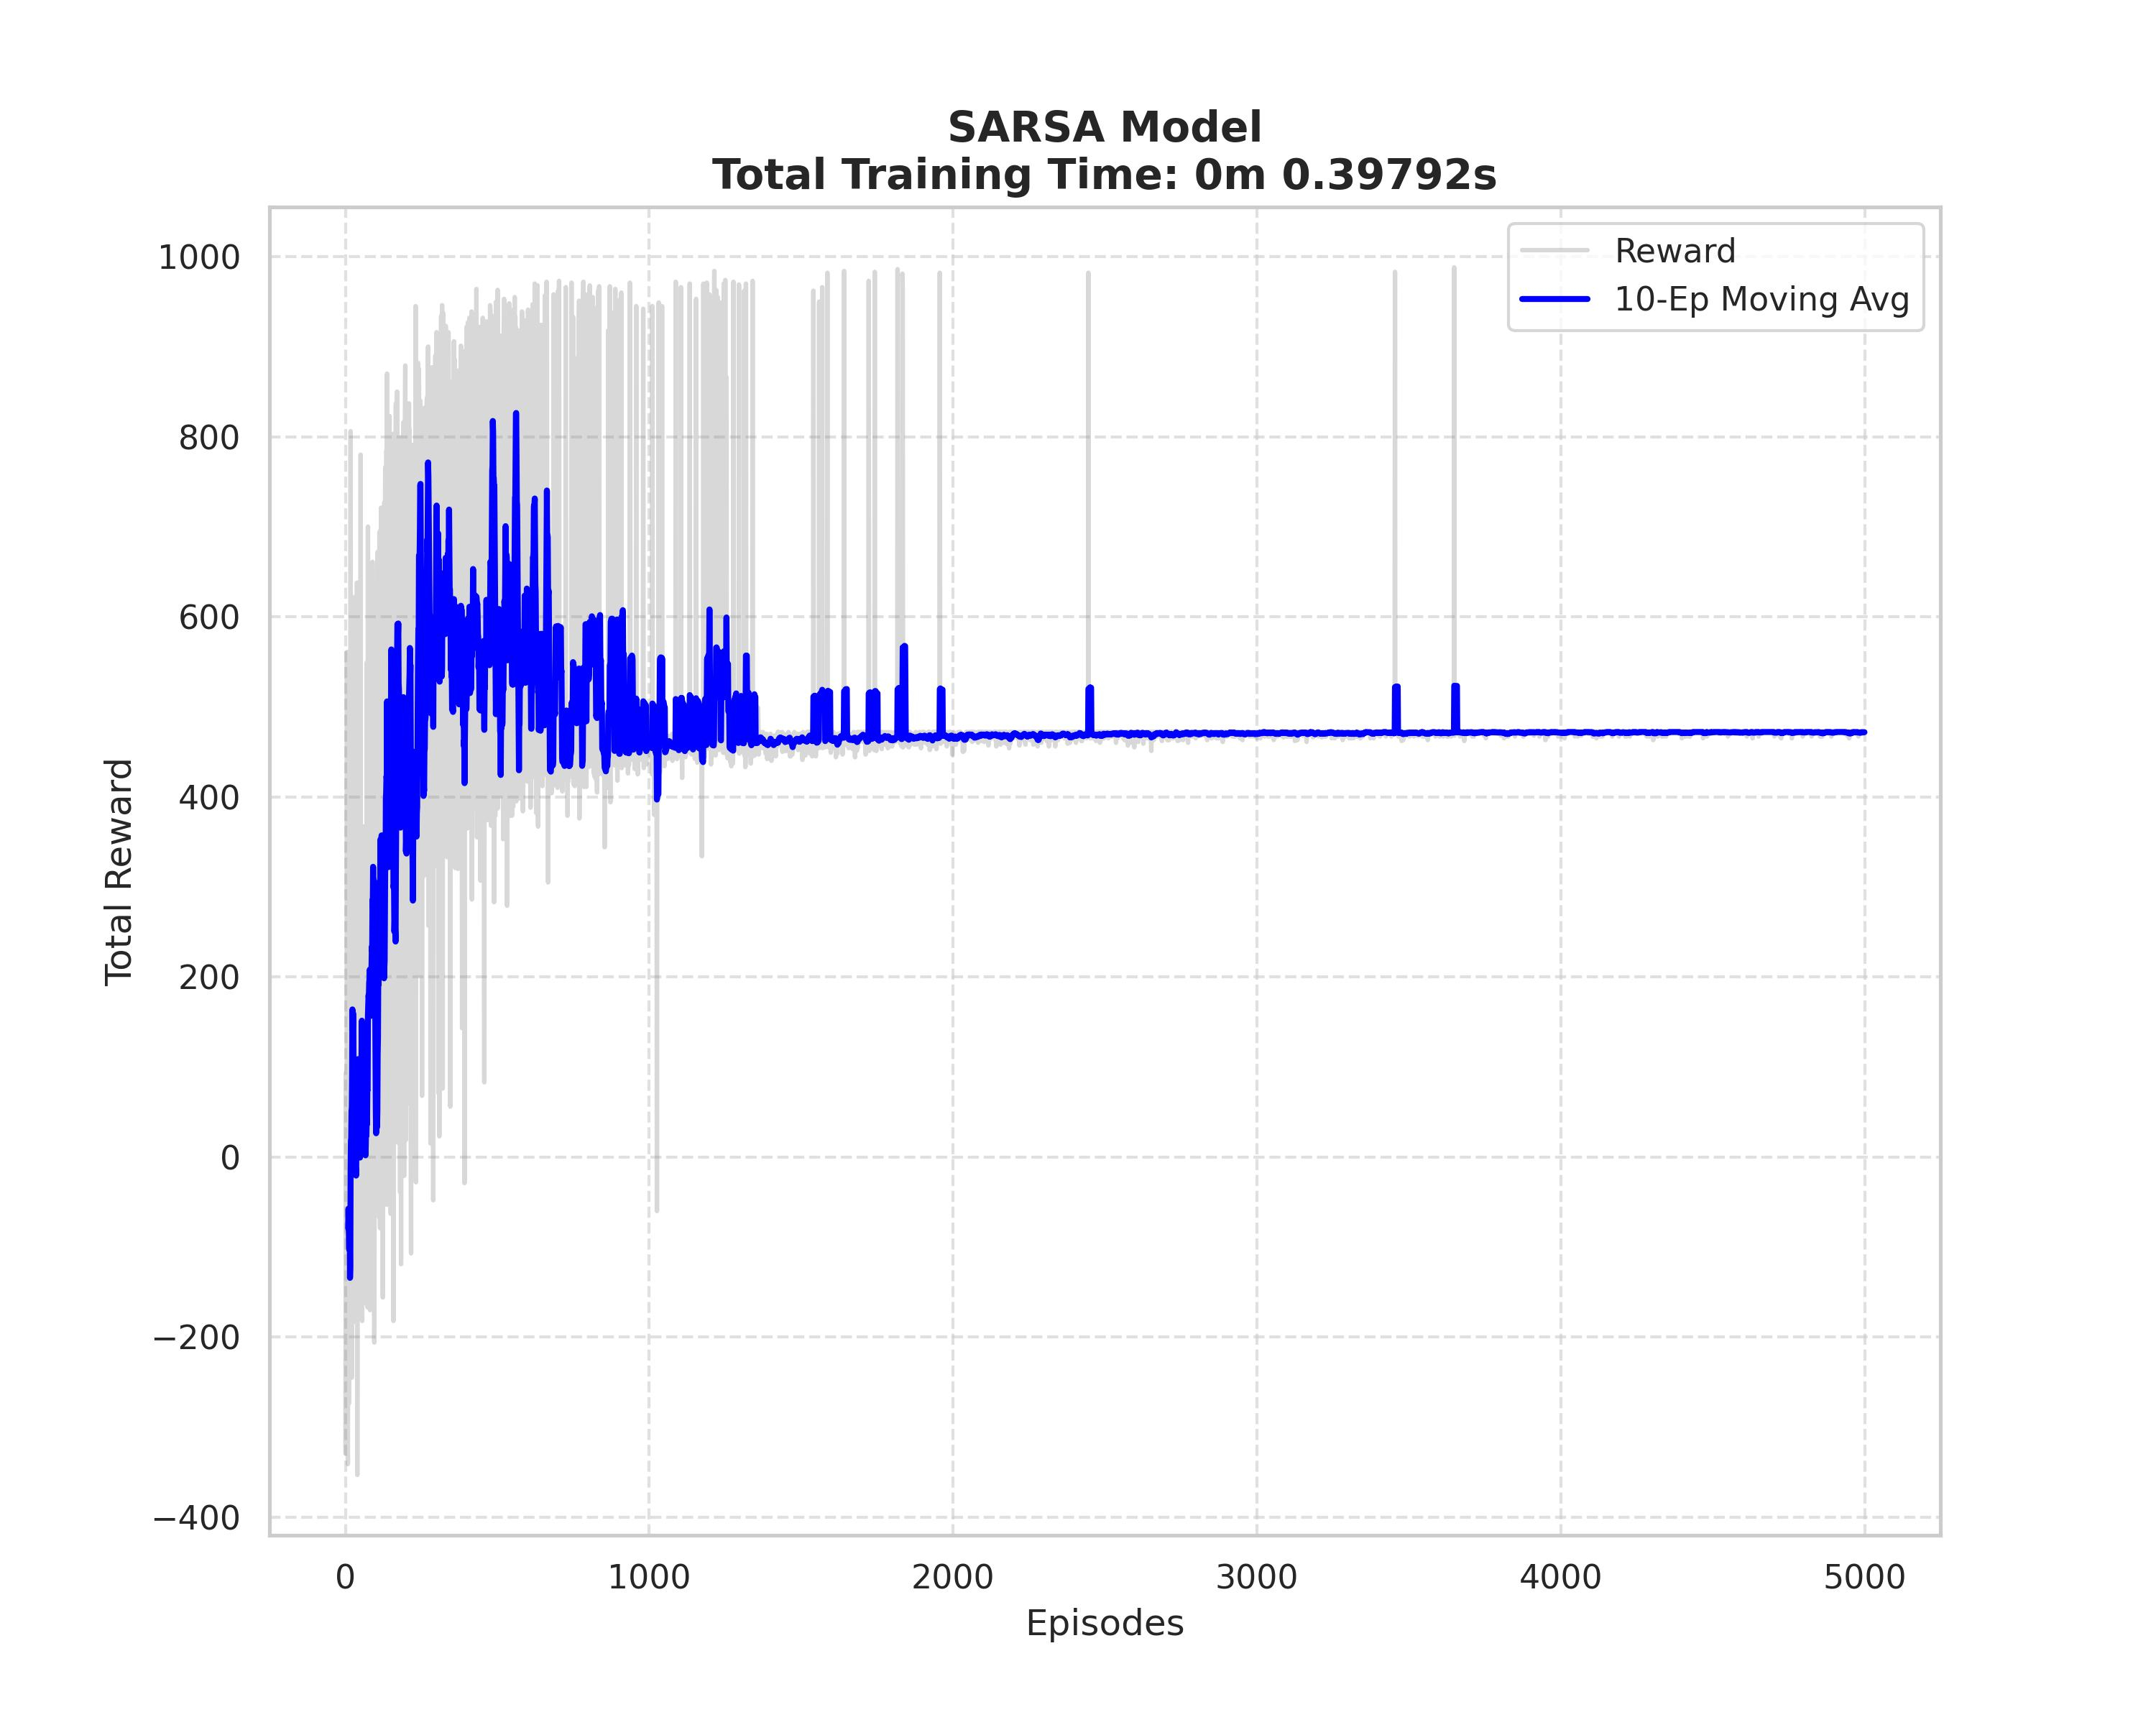

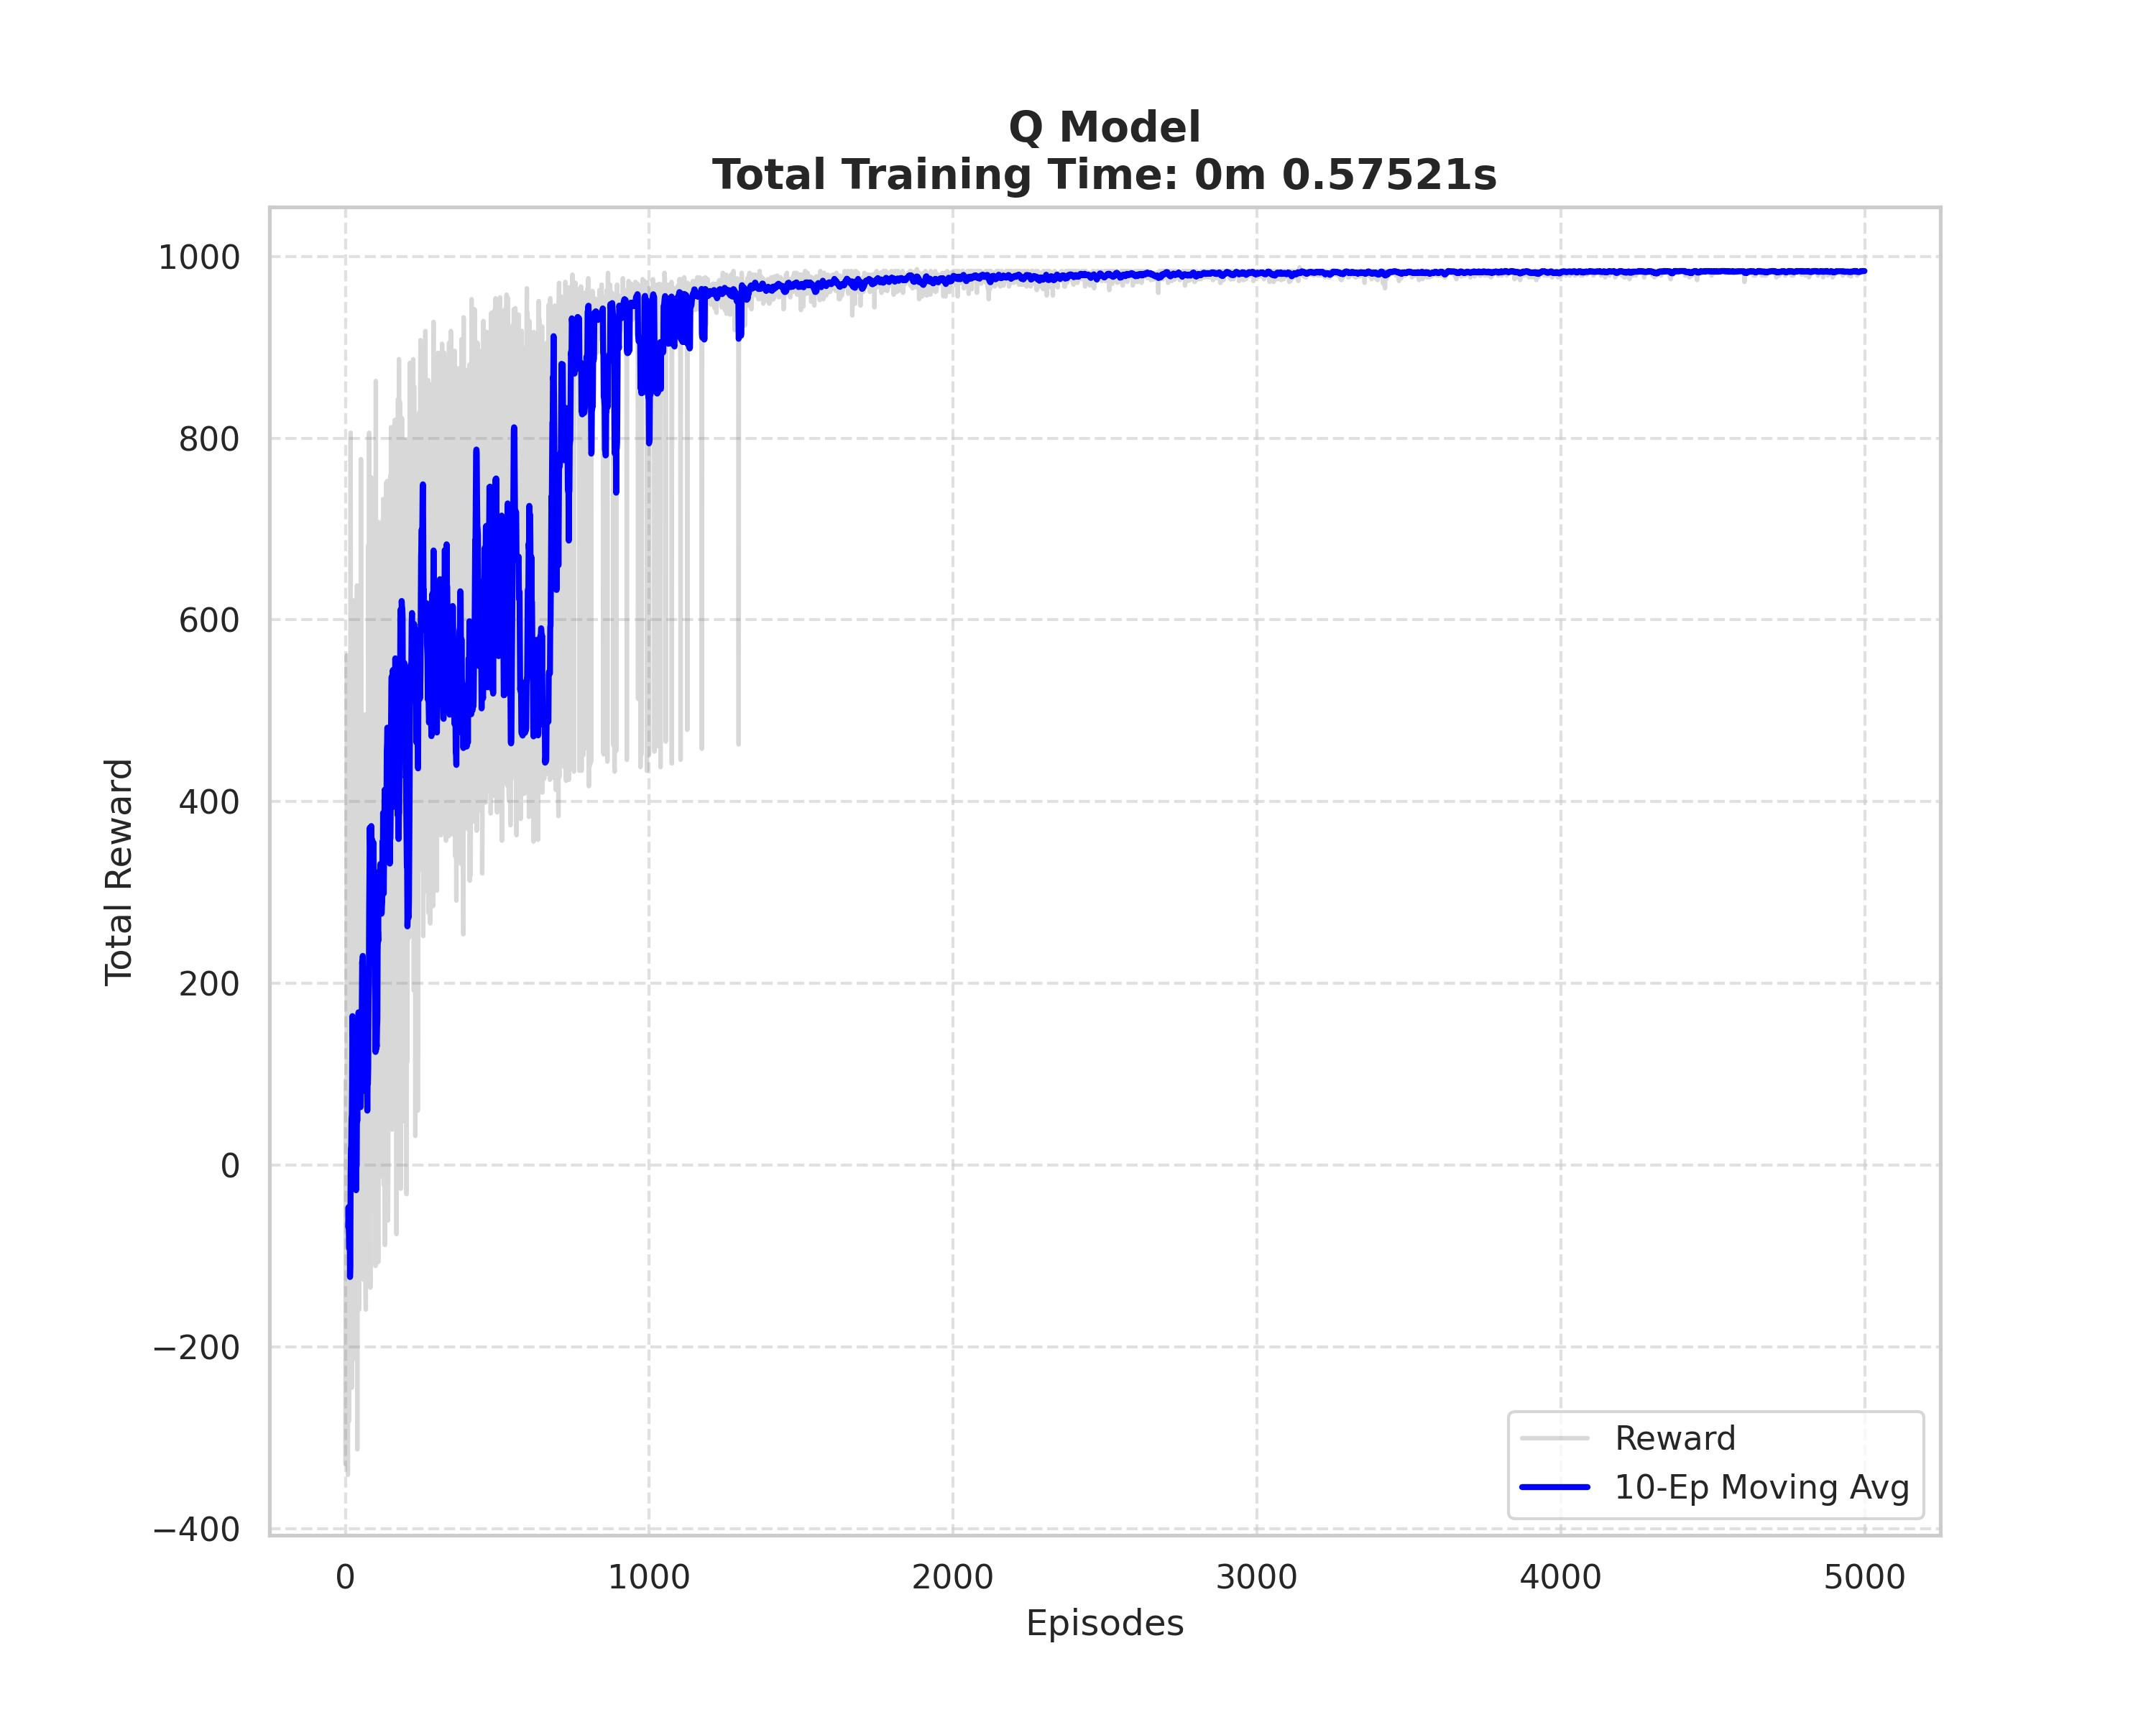

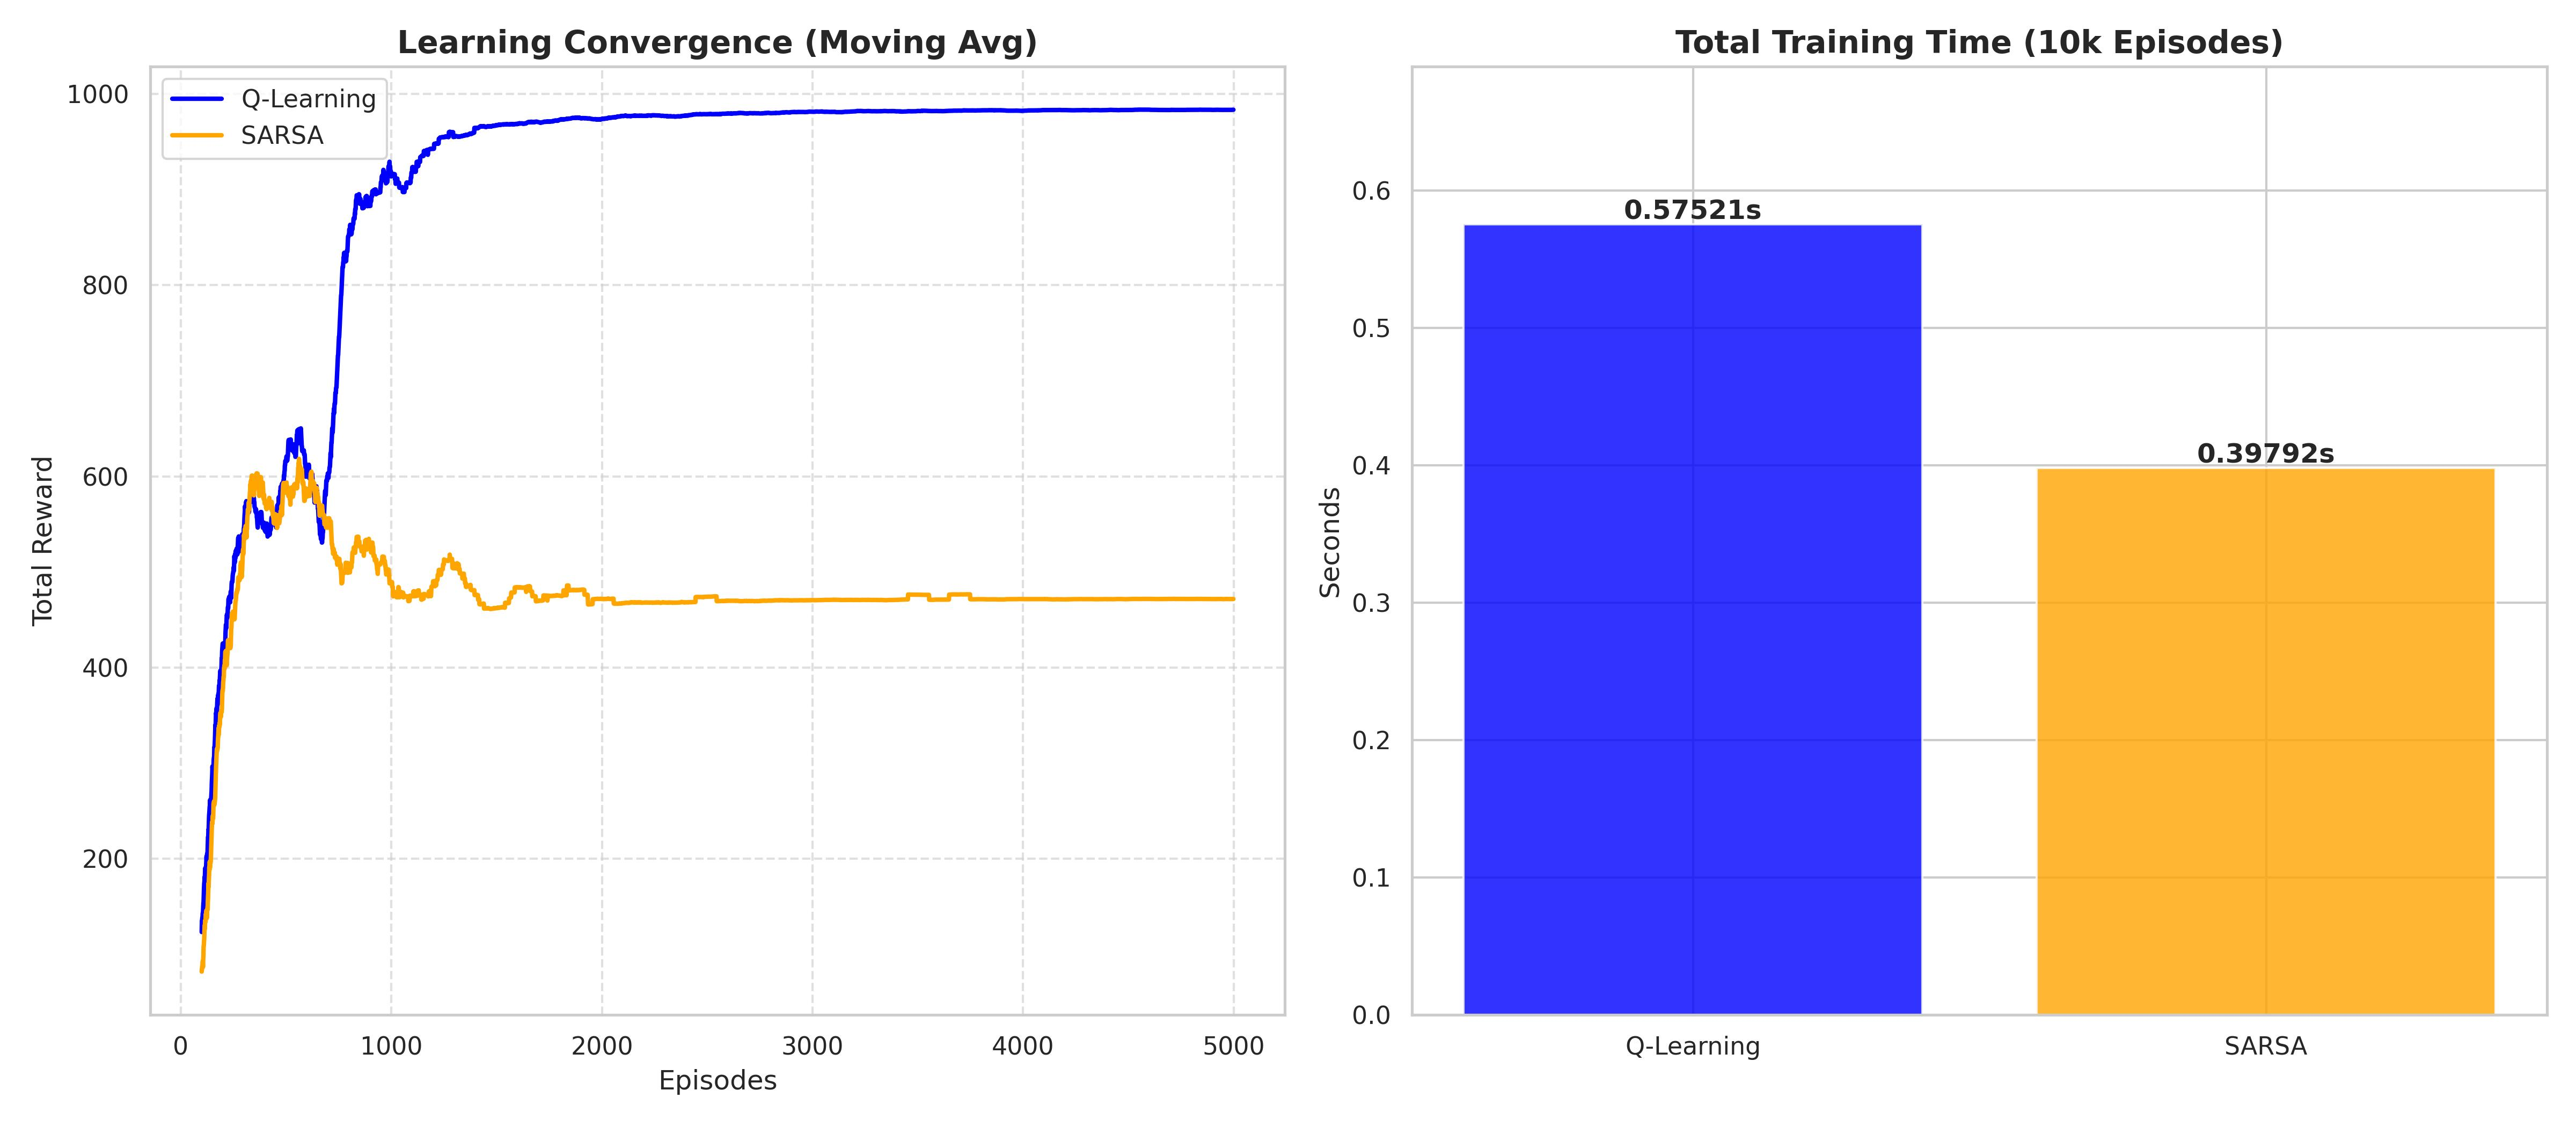

In [ ]:
from RL.train_rl_models import RLTraining
from IPython.display import Image, display

# REINFORCEMENT LEARNING PIPELINE
# print("REINFORCEMENT LEARNING MODELS TRAINING......")
# rl_trainer = RLTraining(episodes=5000, seed=SEED, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
# rl_trainer.train_rl_models()
# print("REINFORCEMENT LEARNING MODELS TRAINING COMPLETE")
# Commented so unneccary print statements doesn't come up.

display(Image(filename='PLOTS/sarsa_training_plot.jpeg'))
display(Image(filename='PLOTS/q_training_plot.jpeg'))
display(Image(filename='PLOTS/rl_model_comparison.jpeg'))

#### <a id="rl_t_eval"></a> 4.1.4 Comparative Training Analysis **(Q Learning vs SARSA)**

Following the execution of the training loop over 5,000 episodes, the learning dynamics and computational efficiency of both agents were recorded. The plots do provide early indicators of how the agents responded to the environment's penalty and reward structure.
1. Both algorithms exhibit a sharp, nearly identical rise in total reward during the initial exploration phase. This occurs because (epsilon) is at its highest, allowing both agents to organically discover the exit and accumulate baseline node rewards.
2. Q-Learning continues to climb aggressively, reaching a near-maximum reward and then plateauing between episodes 1000 and 1500, as it assumes perfect future reward and ignores exploration risk, yielding a high-reward optimized policy.
3. SARSA peaks early near 600, then experiences a significant drop and fluctuation before stabilizing at a plateau just below the 500-point mark. As the exploration rate decays, SARSA continually experiences wall collisions, so it internalizes this risk and abandons the +500 perfect-run path as too dangerous. 
4. The time discrepancy is not due to computational complexity, but due to the physical length of their learned policies. Q-Learning's policy requires it to stay in the maze longer per episode to physically touch every single inspection node, while SARSA learns to exit the maze much earlier.

Note - While these are training metrics, but this shows our earlier theoretical assumptions of high-reward, longer-duration profile of Q-Learning for DEEP SCAN and lower-reward, faster-computation profile of SARSA for QUICK SCAN

---

### <a id="sl_t"></a> 4.2 Supervised Learning

#### <a id="sl_t"></a> **4.2.1 Introduction to Problem Statement**

When the autonomous checking Agent (Navigator) successfully arrives at a spawned node on the factory floor, physical proximity alone is not enough to guarantee operational security. The asset must undergo rigorous digital validation. The Telemetry Validation module represents the first layer of this verification process, and it is tasked with analyzing a data payload, which consisting of 100 temporal telemetry rows, extracted directly from the machine's internal sensors. (csv data)

The primary problem addressed by the Telemetry Validation module is the real-time classification of the asset's identity and its current operational safety state. This is executed through two distinct validation phases:
1. **Level 1 (L1) Identity Validation**: The model must process the 100-row telemetry packet to predict the exact asset classification. Although the facility theoretically houses 5 asset types (Robotic Arm, CNC Machine, PLC Controller, Drone, AGV Unit), the supervised learning problem is explicitly framed as a 7-class classification task. 
2. **Level 2 (L2) Safety Protocol Validation**: Beyond basic identity verification, the system must evaluate specific safety markers to ensure the asset is correctly classified into 7 category.

**Note -** The empirical justification behind expanding the target from 5 to 7 classes will be detailed after the Exploratory Data Analysis (EDA) phase.

#### <a id="sl_eda_"></a> **4.2.2 Exploratory Data Analysis (EDA) of csv**

In [ ]:
import pandas as pd

df = pd.read_csv('data/SensorStats.csv')
df.info()

In [ ]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Excluding Binary Features to see the numbers
features_to_plot = [
    'VOC Emissions', 'Acoustic / Vibration', 'CPU Utilization', 
    'Mechanical Load', 'Axis Elevation / Altitude', 'Actuator Torque', 
    'Thermal Load', 'Compromise Risk Index'
]

# Setting up the plotting grid (4 rows, 2 columns)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 24))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()

for i, feature in enumerate(features_to_plot): 
    active_data = df[df[feature] > 0].dropna(subset=[feature]) # Dropping zera
    
    sns.stripplot(
        data=active_data, 
        x='Asset Class', 
        y=feature, 
        ax=axes[i],
        jitter=True, 
        alpha=0.5,
        palette='Set1',
        size=4
    )
    
    axes[i].set_title(f'{feature} by Asset Class (Non-Zero)', fontsize=20, fontweight='bold')
    axes[i].set_ylabel(feature, fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Finding about Remote Override Flag and Airborne Status
def flag_details(df, cols):

    stats = df.groupby("Asset Class")[cols].agg(["sum", "count"])
    return stats.apply(
        lambda row: f"{int(row['sum'])} / {int(row['count'])}",
        axis=1
    )
 
print("\nRemote Override Flag")
print(flag_details(df, "Remote Override Flag"))
 
print("\nAirborne Status")
print(flag_details(df, "Airborne Status"))

In [ ]:
# Finding how many Compromise Risk Index which are non zeros and Override Active ofr robot_arm
arm_df = df[df['Asset Class'] == 'robot_arm']

print(f"\nTotal Robotic Arms        : {len(arm_df)}")
print(f"Override Flag Active      : {len(arm_df[arm_df['Remote Override Flag'] == 1])}")
print(f"Compromise Risk Index > 0 : {len(arm_df[arm_df['Compromise Risk Index'] > 0])}")

arms_both = len(arm_df[
    (arm_df['Remote Override Flag'] == 1) &
    (arm_df['Compromise Risk Index'] > 0)
])
print(f"Override Active AND Exposed: {arms_both} ")

**NOTE -**

From EDA results, it can be observed that these flags ***"airborne_status"*** and ***"remote_overide_flag"*** are explicitly correlated to only one or two specific asset classes.

If these explicit binary columns are put into the Supervised Learning models as training features, it introduces data leakage. The models would simply memorizing the binary flags to guess the class, instead of learning the complex datas.

To enforce robust learning, a two-step data engineering strategy is implemented:
1. Feature Dropping: We drop these binary  columns from the training and testing feature sets.
2. Class Target Expansion: To ensure the system still detects these critical operational states, we clasify them directly into the target variable. The base **5 classes are expanded to 7** by splitting highly variable assets:
    - **robotic_arm** is divided into **robotic_arm_override** and **robotic_arm_non_override**.
    - **agv_unit** is divided into **agv_units_fly** and **agv_units_non_fly**.

By forcing the model to predict these 7 distinct sub-states using only raw numerical telemetry (Level 1), we guarantee a highly sensitive predictive model. The dropped binary flags are then held back and used exclusively as the physical verification standard during the Level 2 (L2) Safety Protocol check, which validates if the Level 1 prediction matches the machine's actual hardware flag.

In [ ]:
# Plotting All to single Graphs

# As we can see Robot Arms and AGV are divided based on Remote Override Flag and Airborne Status respectively
# So we categories to 7 category
def categorize_detailed(row):
    asset = row["Asset Class"]
    if asset == "robot_arm":
        return "Robotic Arm (Override)" if row["Remote Override Flag"] == 1 else "Robotic Arm (Non Override)"
    elif asset == "agv_units":
        return "AGV Unit (Fly)" if row["Airborne Status"] == 1 else "AGV Unit (No Fly)"
    elif asset == "cnc_machine":
        return "CNC Machine"
    elif asset == "plc_controller":
        return "PLC Controller"
    elif asset == "drone":
        return "Drone"
    return "Unknown"

df['Detailed Asset Class'] = df.apply(categorize_detailed, axis=1)

# Reshaping the data for seaborn graph
melted_df = pd.melt(
    df, 
    id_vars=['Detailed Asset Class'], 
    value_vars=features_to_plot,             
    var_name='Sensor Type',
    value_name='Sensor Value'
)

# Removing  NaN
active_df = melted_df[melted_df["Sensor Value"] > 0].dropna(subset=["Sensor Value"])

# Setting up a custom color palette for all 7 categories
custom_palette = {
    'Robotic Arm (Override)': 'mediumorchid',
    'Robotic Arm (Non Override)': 'darkgray',
    'AGV Unit (Fly)': 'crimson',
    'AGV Unit (No Fly)': 'royalblue',
    'CNC Machine': 'forestgreen',
    'PLC Controller': 'goldenrod',
    'Drone': 'teal'
}
 
# Building the plot
fig, ax = plt.subplots(figsize=(16, 10))
sns.stripplot(
    data=active_df,
    x="Sensor Type",
    y="Sensor Value",
    hue="Detailed Asset Class",
    jitter=True,
    palette=custom_palette,
    size=4,
    dodge=True,
    ax=ax,
)
 
ax.set_title(
    "Sentinel CPS — Physical Sensor Profiles by Detailed Asset Sub-Class",
    fontsize=20
)
ax.set_xlabel("Sensor Type",   fontsize=13, fontweight="bold")
ax.set_ylabel("Raw Sensor Value", fontsize=13, fontweight="bold")
ax.tick_params(axis="x",labelsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(
    title="Detailed Asset Sub-Class",
    title_fontsize=11,
    fontsize=10,
    markerscale=4,
    loc="upper right",
)
 
plt.tight_layout()
plt.savefig("sentinel_sensor_profiles.png", dpi=150)
plt.show()

**Note**

An importnat observation was made regarding the  ***Compromise Risk Index*** column. The values recorded are too high compared to other telemetry. 
In machine learning, algorithms that calculate geometric distance or rely on gradient descent, making them highly sensitive to unscaled data. So to ensure a balanced and highly sensitive L1 classification, Standardization is needed. This make sure that every sensor reading contributes proportionally to the final prediction.

[Back to Mapping](#map)

#### <a id="sl_t_why"></a> 4.2.3 **Justification for Algorithm Choice**

In Industrial environment, where highly complex and non-linear data are streaming, discrete classifications are insufficient and require explainablity. Hence, simple linear models and DNNs are not suitablefor this task, despite their ability to output *confidence probabilities* for predictions.

This narrows our selection to the two most robust, explainable, non-linear architectures: Random Forest and Support Vector Machines (SVM). These two models is compared to evaluate how distinct mathematical approaches generate confidence scores.
1. **Random Forest (The Probabilistic Ensemble)**
    * Mechanism: Constructs a forest of independent decision trees during training.
    * Confidence Generation: It natively calculates prediction confidence based on ensemble voting.
    * Advantage: It is highly robust against overfitting and provides built-in feature importance metrics, helping to narrow down to see which telemetry sensors are driving the predictions.
2. **Support Vector Machine (The Geometric Boundary)**
    * Mechanism: This maps the scaled telemetry data into a high-dimensional space to find the optimal hyperplane separating the classes.
    * Confidence Generation (Platt Scaling): Standard SVMs calculate geometric distance, not probability. To meet our confidence requirement, the SVM must be calibrated using Platt Scaling (fitting a logistic regression model to the SVM's scores) to convert geometric distances into strict probability percentages.
    * Advantage: Given that our data is explicitly scaled, SVMs are incredibly powerful at drawing crisp, rigid mathematical boundaries between highly similar sub-states (e.g., distinguishing a standard robotic_arm from an overridden one).

**Note -**  It is important to note that EDA confirmed the engineered telemetry dataset is highly structured and clean. From a purely statistical point, simpler baseline models (e.g., Logistic Regression or k-NN) could technically achieve acceptable classification accuracy. The selection of Random Forest and SVM was deliberately driven by the operational constraints of our Industrial OT narrative, specifically the non-negotiable requirements for feature explainability and mathematically calibrated confidence scores.

#### <a id="sl_t_m"></a> 4.2.4 **Implementation and Data Flow of Both Method** (RF vs SVM)

#### <a id="sl_t_eval"></a> 4.2.5 **Comparative Training Analysis **(RF vs SVM)

[Back to Flow](#flow)

now for report_pipeline.py

1. We'll run the inference and get the plots for all individual models and overall report
2. finally We create a report table df1 with these columns:
    * Ground Truth (this will be taken from spnwer)
    * Does it have airborne_status (Ground_truth)
    * Does it have remote_override_flag (ground_truth)
    * SL_answer
    * SL_conf
    * Does_match with ground_truth with more than 98% conf (if yes, level 1 cleared)
         - ex - If SL AGV (fly or no fly) matches with ground_truth AGV and level 1 check complete
    * Does it mathces override_flag or airborne_status (as Sl will divide into 7 classfication, so we'll know if it is flaged with these) (if yes level 2 is cleared)
        - ex - if SL AGV (fly) means Airbone_status(from ground truth) should be true, if not level 2 fails. same for robotic_arm in overide case.
    * USL_answer
    * USL_conf
    * Does_match with ground_truth with more than 95% conf (if yes, level 3 cleared)
    * Level_cleared (1 or 2 or 3)
3. Another table df2 where I run multiple runs with different combinations of models (We'll be specfy which model we are choosing for SL, usl, RL, at start of every run)
    * USL_model
    * SL_model
    * RL_model
    * Points_level_cleared (if all 3 level is cleared than 3 points, if only 2 level are cleared than only 2 points and same for 1, so max point is 30, 3x10 10, locations)
    * Total rewards collected by RL
    * Time taken by RL model to complete (this will be)
4. We have to see (visualize) the arrow navigating rl env.
5. Rows will be 10 locations which is set by spanwer for df1, it also collect 100 rows and 100 images


# Training

SUPERVISED LEARNING MODELS TRAINING......

Training Random Forest........
Random Forest trained successfully in 0.04801 seconds.

Training SVM........
SVM trained successfully in 1.70023 seconds.
SUPERVISED LEARNING MODELS TRAINING COMPLETE

UNSUPERVISED LEARNING MODELS TRAINING......

Starting CAE Training...
Locking down randomness with seed: 47
Dataset Split → 6414 training images / 1604 validation images
Epoch [1/20] | Train Loss: 0.057349 | Val Loss: 0.016747
Epoch [2/20] | Train Loss: 0.014723 | Val Loss: 0.013011
Epoch [3/20] | Train Loss: 0.011699 | Val Loss: 0.011284
Epoch [4/20] | Train Loss: 0.010533 | Val Loss: 0.010190
Epoch [5/20] | Train Loss: 0.009366 | Val Loss: 0.009123
Epoch [6/20] | Train Loss: 0.008443 | Val Loss: 0.008298
Epoch [7/20] | Train Loss: 0.007758 | Val Loss: 0.007823
Epoch [8/20] | Train Loss: 0.007308 | Val Loss: 0.007345
Epoch [9/20] | Train Loss: 0.006896 | Val Loss: 0.007057
Epoch [10/20] | Train Loss: 0.006562 | Val Loss: 0.006758
Epoch [11/20] | T

CV Features: 100%|██████████| 8018/8018 [00:11<00:00, 685.66it/s]


Training Data Saved! Final tensor shape: (8018, 16)

Training USL Model - GMM...
Features loaded successfully. Shape: (8018, 16)
Fitting GMM with 5 components...
GMM converged in 13 iterations.
GMM model saved to: MODELS/gmm_model.pkl
GMM Training finished in 20.85923s

Training USL Model - DEC...
Locking down randomness with seed: 47
Running BIRCH to generate pseudo-labels for warm-up phase...
Training DEC: 15 Epochs CE Warm-Up -> 65 Epochs
Epoch [10/80] | Warm-Up | Train Loss: 0.0314 | Val Loss: 0.0452
Epoch [20/80] | Self-Supervised | Train Loss: 0.0076 | Val Loss: 0.0079
Epoch [30/80] | Self-Supervised | Train Loss: 0.0038 | Val Loss: 0.0047
Epoch [40/80] | Self-Supervised | Train Loss: 0.0027 | Val Loss: 0.0033
Epoch [50/80] | Self-Supervised | Train Loss: 0.0022 | Val Loss: 0.0028
Epoch [60/80] | Self-Supervised | Train Loss: 0.0016 | Val Loss: 0.0027
Epoch [70/80] | Self-Supervised | Train Loss: 0.0014 | Val Loss: 0.0025
Epoch [80/80] | Self-Supervised | Train Loss: 0.0009 | Val

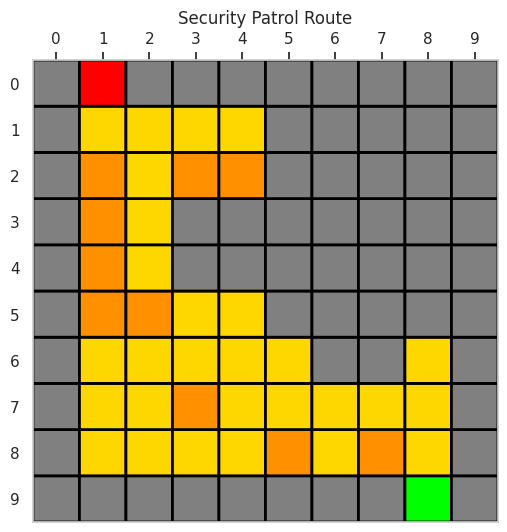

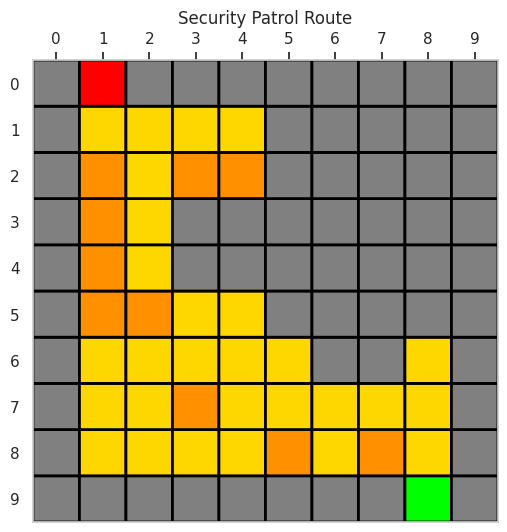

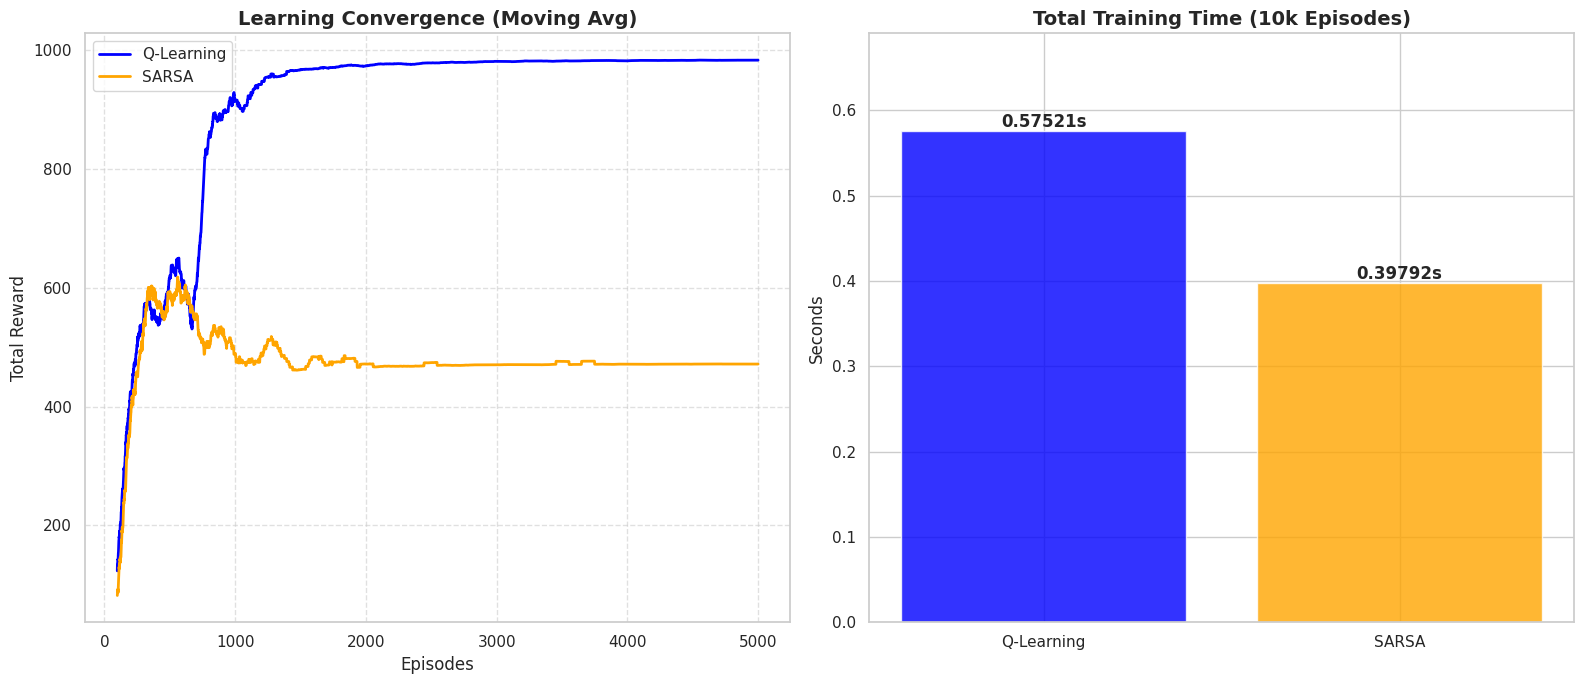

In [ ]:
"""
File: train_all.py
This script serves as the master execution hub for the entire project, orchestrating
the training pipelines for Supervised Learning (SL), Unsupervised Learning (USL),
and Reinforcement Learning (RL) sequentially.


from pathlib import Path
from mapping import map_csv, map_imgs
from SL_training.train_sl_models import SLTraining
from USL_training.train_usl_models import USLTraining
from RL_training.train_rl_models import RLTraining


if __name__ == "__main__":

    # CREATING FOLDERS
    IMG_PATH = "DATA/DATASET"
    CSV_PATH = "DATA/SENSOR_STATS.csv"
    PLOT_PATH = "PLOTS/"
    MODEL_PATH = "MODELS/"
    SEED = 47
    if not Path(CSV_PATH).exists(): map_csv()
    if not Path(IMG_PATH).exists(): map_imgs()
    Path(PLOT_PATH).mkdir(parents=True, exist_ok=True) # For All Plots
    Path(MODEL_PATH).mkdir(parents=True, exist_ok=True) # For All Models

    # SUPERVISED LEARNING PIPELINE
    print("SUPERVISED LEARNING MODELS TRAINING......")
    sl_trainer = SLTraining(seed=SEED, data_path=CSV_PATH, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
    sl_trainer.train_sl_models()
    print("SUPERVISED LEARNING MODELS TRAINING COMPLETE\n")

    # UNSUPERVISED LEARNING PIPELINE
    print("UNSUPERVISED LEARNING MODELS TRAINING......")
    usl_trainer = USLTraining(seed=SEED, data_dir=IMG_PATH, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
    usl_trainer.train_usl_models()
    print("UNSUPERVISED LEARNING MODELS TRAINING COMPLETE\n")

    # REINFORCEMENT LEARNING PIPELINE
    print("REINFORCEMENT LEARNING MODELS TRAINING......")
    rl_trainer = RLTraining(episodes=5000, seed=SEED, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
    rl_trainer.train_rl_models()
    print("REINFORCEMENT LEARNING MODELS TRAINING COMPLETE")
"""


# Inference

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from collections import Counter

from RL_env.spanwer import DataSpawner
from RL_env.env_gen import MapGenerator
from SL_training.sl_inference import SLInference
from USL_training.usl_inference import USLInference
from RL_training.rl_inference import RLInference

SL_MODELS  = ["rf_model.pkl",    "svm_model.pkl"]
USL_MODELS = [("gmm", "gmm_model.pkl"), ("dec", "dec_model.pt")]
RL_MODELS  = ["q_brain.json",    "sarsa_brain.json"]

def parse_label(label):
    if label.startswith("robotic_arm"):
        return "robotic_arm", label[12:]
    elif label.startswith("agv_unit"):
        return "agv_unit", label[9:]
    else:
        parts = label.split("_")
        return parts[0], "_".join(parts[1:])

def evaluate_levels(gt, air, override, sl_ans, sl_conf, usl_ans, usl_conf):
    gt_base, _          = parse_label(gt)
    sl_base, sl_attrs   = parse_label(sl_ans)
    l1 = (sl_base == gt_base) and (sl_conf > 0.98)
    fly_ok      = ("fly" in sl_attrs) if air else ("non_fly" in sl_attrs or "fly" not in sl_attrs)
    override_ok = ("override" in sl_attrs) if override else ("non_override" in sl_attrs or "override" not in sl_attrs)
    l2 = fly_ok and override_ok
    l3 = (usl_ans == gt) and (usl_conf > 0.95)
    return l1, l2, l3, int(l1) + int(l2) + int(l3)

def aggregate_usl_result(result, class_names):
    majority_cluster = Counter(result.predictions).most_common(1)[0][0]
    majority_mask    = result.predictions == majority_cluster
    return class_names[majority_cluster], float(np.mean(result.confidences[majority_mask]))

def combo_tag(sl_file, usl_name, rl_file):
    sl = sl_file.replace(".pkl", "").replace(".pt", "")
    rl = rl_file.replace(".json", "")
    return f"{sl}__{usl_name}__{rl}"

In [ ]:
'''
Path("RESULTS").mkdir(exist_ok=True)
print("[1] Initializing Data Spawner and Environments...")
spawner = DataSpawner(csv_path="DATA/SENSOR_STATS.csv", image_dir="DATA/DATASET")
map_gen = MapGenerator(seed=47)
map_gen.generate_map()

# Consolidated containers
all_df1_rows = []
df2_rows = []

total_pipeline_time = 0.0
combo_count = 0

# Grid Search: 8 combinations
for sl_file, (usl_name, usl_file), rl_file in product(SL_MODELS, USL_MODELS, RL_MODELS):
    combo_count += 1
    tag = combo_tag(sl_file, usl_name, rl_file)
    print(f"\n[Combo {combo_count}/8] Running: {tag}")

    # Load models
    sl_engine  = SLInference(model_dir="MODELS",  model_file=sl_file)
    usl_engine = USLInference(model_dir="MODELS", pipeline_name=usl_name, seed=47)
    rl_engine  = RLInference(model_dir="MODELS",  qtable_file=rl_file)

    combo_total_time = 0.0
    level_cleared_sum = 0

    # --- SL & USL Evaluation ---
    for loc_id in range(10):
        target_class, sampled_rows_df, images_paths, gt_air, gt_override = spawner.get_payload(loc_id)

        sl_ans, sl_conf, sl_time = sl_engine.run(sampled_rows_df.to_dict('records'))
        usl_result = usl_engine.run(images_paths)
        usl_ans, usl_conf = aggregate_usl_result(usl_result, spawner.classes)
        usl_time = usl_result.elapsed_sec

        combo_total_time += sl_time + usl_time

        l1, l2, l3, lvl = evaluate_levels(
            target_class, gt_air, gt_override,
            sl_ans, sl_conf, usl_ans, usl_conf
        )
        level_cleared_sum += lvl

        # Append to master DF1 list with model identifiers
        all_df1_rows.append({
            "Location_ID": loc_id,
            "Ground_Truth": target_class, "Airborne_(GT)": gt_air, "Override_(GT)": gt_override,
            "SL_Answer": sl_ans, "SL_Conf": sl_conf,
            "USL_Answer": usl_ans, "USL_Conf": usl_conf,
            "L1_Cleared": l1, "L2_Cleared": l2, "L3_Cleared": l3, "Level_Cleared": lvl,
            "USL_Model": usl_file, "SL_Model": sl_file, "RL_Model": rl_file
        })

    # --- RL Navigation ---
    gif_path = f"RESULTS/rl_animation__{tag}.gif"
    path, reward, rl_time = rl_engine.run(map_gen, animate=True, gif_path=gif_path)

    combo_total_time += rl_time
    total_pipeline_time += combo_total_time

    # Append to DF2 list
    df2_rows.append({
        "SL_Model": sl_file,
        "USL_Model": usl_file,
        "RL_Model": rl_file,
        "Points_Level_Cleared": level_cleared_sum,
        "Total_Rewards_Collected": round(reward, 4),
        "Time_Taken_RL": round(rl_time, 4),
        "Total_Time": round(combo_total_time, 4)
    })

# --- SAVE CONSOLIDATED DF1 ---
df1 = pd.DataFrame(all_df1_rows)
df1_cols = [
    "Location_ID", "Ground_Truth", "Airborne_(GT)", "Override_(GT)", 
    "SL_Answer", "SL_Conf", "USL_Answer", "USL_Conf", 
    "L1_Cleared", "L2_Cleared", "L3_Cleared", "Level_Cleared", 
    "USL_Model", "SL_Model", "RL_Model"
]
df1 = df1[df1_cols]
df1.to_csv("RESULTS/df1_all_combinations.csv", index=False)

# --- SAVE CONSOLIDATED DF2 ---
df2 = pd.DataFrame(df2_rows)
df2_cols = [
    "SL_Model", "USL_Model", "RL_Model", 
    "Points_Level_Cleared", "Total_Rewards_Collected", 
    "Time_Taken_RL", "Total_Time"
]
df2 = df2[df2_cols]
df2.to_csv("RESULTS/df2_all_combinations.csv", index=False)

print(f"\n{'='*60}")
print(f"Grid Search Complete. Results saved in 'RESULTS/' folder.")
print(f"Total Combined Rows in DF1: {len(df1)}")
print(f"Animations Generated: {combo_count}")
print(f"Grand Total Pipeline Time: {total_pipeline_time:.2f}s")
print(f"{'='*60}")
'''

In [ ]:
import pandas as pd

df1 = pd.read_csv("RESULTS/df2_all_combinations.csv")
df1.head (30)

,SL_Model,USL_Model,RL_Model,Points_Level_Cleared,Total_Rewards_Collected,Time_Taken_RL,Total_Time
0,rf_model.pkl,gmm_model.pkl,q_brain.json,21,975,1.4318,4.1898
1,rf_model.pkl,gmm_model.pkl,sarsa_brain.json,21,465,0.9484,2.4253
2,rf_model.pkl,dec_model.pt,q_brain.json,22,975,1.3717,2.9739
3,rf_model.pkl,dec_model.pt,sarsa_brain.json,22,465,0.8969,2.6890
4,svm_model.pkl,gmm_model.pkl,q_brain.json,19,975,1.4284,3.4463
5,svm_model.pkl,gmm_model.pkl,sarsa_brain.json,19,465,0.8982,2.9460
6,svm_model.pkl,dec_model.pt,q_brain.json,20,975,1.3884,3.4314
7,svm_model.pkl,dec_model.pt,sarsa_brain.json,20,465,0.8877,2.8587


In [ ]:
df2 = pd.read_csv("RESULTS/df1_all_combinations.csv")
df2.head (10)

,Location_ID,Ground_Truth,Airborne_(GT),Override_(GT),SL_Answer,SL_Conf,USL_Answer,USL_Conf,L1_Cleared,L2_Cleared,L3_Cleared,Level_Cleared,USL_Model,SL_Model,RL_Model
0,0,agv_unit,1,0,agv_unit_fly,0.981,plc_controller,0.979559,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
1,1,robotic_arm,0,1,robotic_arm_override,1.000,cnc_machine,0.979435,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
2,2,robotic_arm,0,1,robotic_arm_override,0.995,cnc_machine,0.948176,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
3,3,plc_controller,0,0,plc_controller,0.999,cnc_machine,0.952069,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
4,4,drone,1,0,drone_fly,0.997,drone,0.944511,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
5,5,cnc_machine,0,0,cnc_machine,1.000,robotic_arm,0.981400,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
6,6,plc_controller,0,0,plc_controller,0.998,cnc_machine,0.955889,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
7,7,plc_controller,0,0,plc_controller,1.000,cnc_machine,0.944246,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
8,8,agv_unit,0,0,agv_unit_non_fly,0.983,plc_controller,0.964507,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
9,9,drone,1,0,drone_fly,0.997,drone,0.958356,True,True,True,3,gmm_model.pkl,rf_model.pkl,q_brain.json


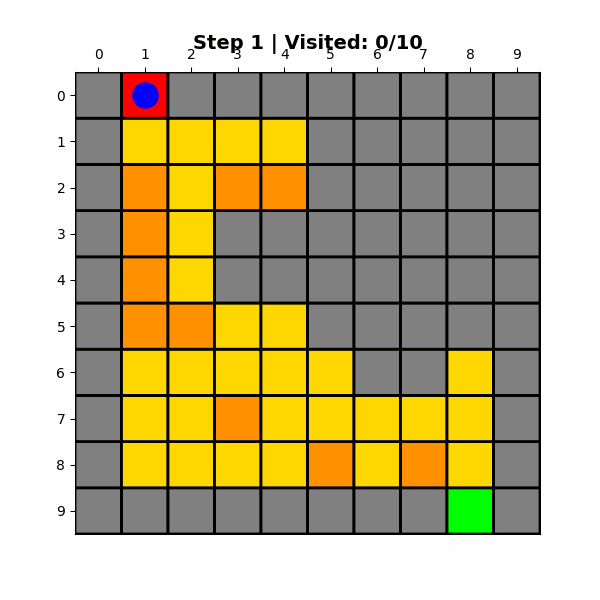

In [10]:
from IPython.display import Image

# Display the GIF
Image(filename='rl_agent_navigation.gif')